# Python Visualiser

Python tool to help visualise and analyse the outputs of the C++ programs.

In [419]:
import pandas as pd 
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from scipy.stats import norm, skew, kurtosis

### Visualise Simulations

In [310]:
# --- BlackScholes 1D Diffusions ---
# filepath = r"Outputs/PseudoBSEuler1D_Simulations.csv"
# filepath = r"Outputs/QuasiBSEuler1D_Simulations.csv"

# --- BlackScholes ND Diffusions ---
# filepath = r"Outputs/PseudoBSEulerND_Simulations.csv"
# filepath = r"Outputs/QuasiBSEulerND_Simulations.csv"

# --- Basket Diffusions ---
# filepath = r"Outputs/PseudoBasketBSEuler_Simulations.csv"
# filepath = r"Outputs/QuasiBasketBSEuler_Simulations.csv"


# --- Monte Carlo Simulations ---
filepath = r"Outputs/MonteCarlo_Simulations.csv"

# --- Longstaff Schwarz Simulations ---
# filepath = r"Outputs/LSBasket_Simulations.csv"

In [311]:
# filepath = r"Outputs/MonteCarlo_Simulations.csv"

<bound method DataFrame.info of       0         1         2         3         4         5         6    \
0     100  107.4540  110.8990  113.1720  117.2400  118.2890  122.6210   
1     100  101.5210  100.1120  101.3580  100.5610  100.7340   99.5614   
2     100   99.2685   98.7296   97.3782   98.5737  103.3100  104.0210   
3     100  101.6670  103.3000   98.7832   98.5599  100.6700  100.8230   
4     100  103.8690  100.9650  102.8600  100.1040  100.6920   99.3469   
...   ...       ...       ...       ...       ...       ...       ...   
1195  100  100.5830   98.6081   98.3388  102.3870  101.9250   96.3229   
1196  100   99.6293  100.6290   97.4402   98.8252   97.6748   97.2113   
1197  100  102.7140  104.8460  109.3600  109.5090  109.4570  109.3050   
1198  100   98.3991   99.3930  100.0930  100.6450  101.2540  102.9470   
1199  100  100.9980  102.9020  104.2970  104.3590  104.0600  104.1220   

           7         8         9    ...       243       244       245  \
0     125.0400  12

,0,1,2,3,4,5,6,7,8,9,...,1190,1191,1192,1193,1194,1195,1196,1197,1198,1199
0,0.019103,0.000041,-0.000738,0.000693,-0.000902,0.000304,0.001260,-0.001314,-2.066946e-04,-0.000492,...,0.000742,-0.000007,-0.000489,-0.000435,0.000520,0.000650,-0.000188,0.000463,0.000768,0.001654
1,0.000041,0.013723,-0.001589,-0.000198,0.000781,-0.000817,0.000118,0.000662,-6.912660e-04,-0.000376,...,0.000272,0.001085,0.001072,0.000626,0.000627,0.001189,0.000645,0.000704,-0.001240,-0.000287
2,-0.000738,-0.001589,0.013501,-0.000214,-0.000247,0.000392,-0.000542,-0.001317,-5.570303e-04,-0.000007,...,-0.000993,0.001336,0.000322,0.001125,-0.001363,-0.000340,-0.000216,-0.002006,-0.000346,0.000315
3,0.000693,-0.000198,-0.000214,0.011174,-0.000275,-0.000304,0.000812,0.000167,-2.714755e-04,0.000346,...,0.000489,-0.001091,0.000322,-0.000240,0.001296,0.000475,-0.000824,-0.000251,-0.000573,0.000079
4,-0.000902,0.000781,-0.000247,-0.000275,0.018021,-0.001017,0.000253,-0.000061,-5.020087e-04,-0.000406,...,-0.000371,0.000034,0.000705,0.001484,0.001207,0.001849,-0.000294,0.000827,-0.000041,0.000551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.000650,0.001189,-0.000340,0.000475,0.001849,0.000030,0.000515,-0.000331,1.519763e-04,-0.000177,...,-0.000833,0.000900,-0.000025,0.001742,-0.000383,0.012698,-0.000661,-0.000101,-0.000072,0.000792
1196,-0.000188,0.000645,-0.000216,-0.000824,-0.000294,0.001011,0.000645,0.000541,-1.764246e-03,-0.001019,...,-0.001995,-0.000797,0.000245,-0.000102,-0.002690,-0.000661,0.018687,0.000552,-0.001641,0.001347
1197,0.000463,0.000704,-0.002006,-0.000251,0.000827,-0.000543,-0.001006,0.001269,6.806129e-07,0.000401,...,-0.000597,-0.001340,0.000054,-0.001104,-0.000172,-0.000101,0.000552,0.010268,0.001780,0.001055
1198,0.000768,-0.001240,-0.000346,-0.000573,-0.000041,-0.000934,-0.000303,0.000452,2.347255e-04,0.000236,...,-0.000319,-0.000263,0.000309,-0.000334,-0.001220,-0.000072,-0.001641,0.001780,0.012879,0.000205


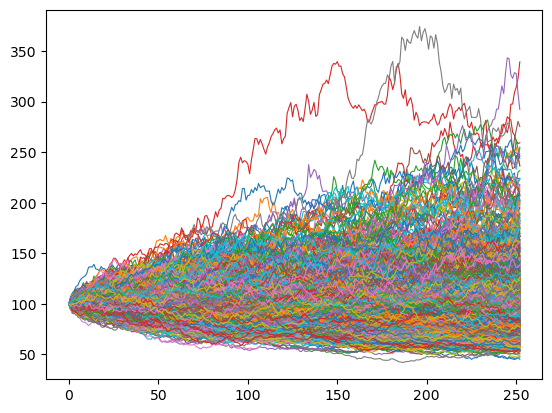

In [312]:
# Load the data
df_data = pd.read_csv(filepath, header=None)
print(df_data.info)
# Plot the data
df_data.T.iloc[:, :].plot(linewidth=0.8, legend=False)

# Compute summary statistics on the returns
nbSteps = 1000
dt = 1 / nbSteps
df_returns = df_data.iloc[:, :].T.pct_change().dropna()
print(f"Annualised return")
print(df_returns.mean() * nbSteps)
print("\n")
print(f"Annualised Volatilities")
print(df_returns.std() * np.sqrt(nbSteps))
print("\n")
print(f"Annualised Covariance Matrix")
df_returns.cov().apply(lambda x: x/np.sqrt(dt))

In [313]:
# BlackScholes price
df_data.iloc[:, -1].apply(lambda x: max(x - 100.0, 0)).mean() * np.exp(-0.05)

15.509806071469574

<Axes: ylabel='Frequency'>

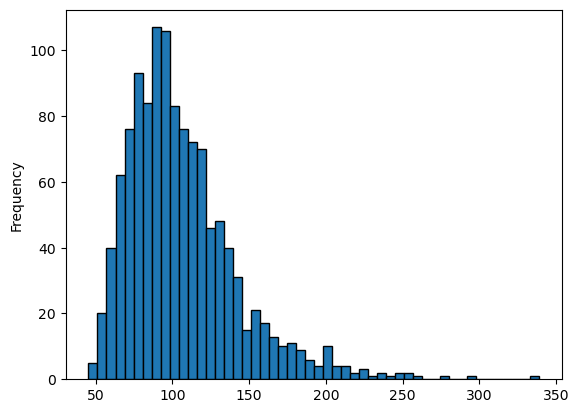

In [314]:
df_data.iloc[:, -1].plot(kind="hist", bins = 50, edgecolor='black')

In [315]:
print(f"Average terminal value: {df_data.iloc[:, -1].mean()}")
print(f"Variance of terminal values: {df_data.iloc[:, -1].var()}")

Average terminal value: 106.21002241666666
Variance of terminal values: 1312.2648288436253


With Pseudo Random Numbers:
- Average terminal value: 105.1860216
- Variance of terminal values: 109.72982458363701

With Quasi Random Numbers:
- Average terminal value: 104.598503
- Variance of terminal values: 1.1467280500410397

[]

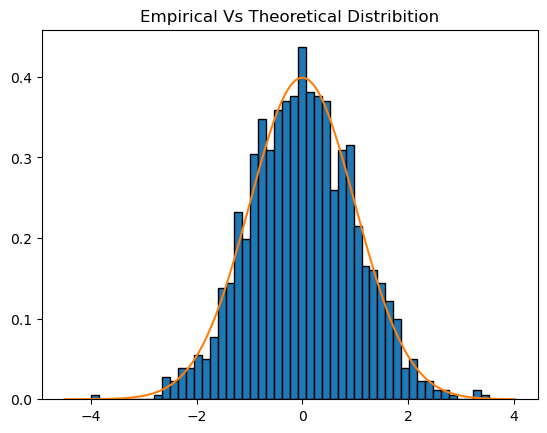

In [308]:
# Statistical analysis
df_plot = df_data.iloc[:, -1].apply(lambda x: np.log(x))
df_plot = (df_plot - df_plot.mean()) / df_plot.std()

# Theoretical distribution
x = np.linspace(df_plot.min()-0.5, df_plot.max()+0.5, 500)
pdf = norm.pdf(x, loc=0, scale=1)

# Plot
plt.hist(df_plot, 50, density=True, edgecolor='black', label="Spots at maturity")
plt.plot(x, pdf, label="Theoretical Distribution")
plt.title("Empirical Vs Theoretical Distribition")
plt.plot()

In [309]:
mean = df_plot.mean()
var = df_plot.var() 
skewness = skew(df_plot)
kurt = kurtosis(df_plot, fisher=True)

print(f"Mean: {mean:.4f}")
print(f"Variance: {var:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis (excess): {kurt:.4f}")

Mean: 0.0000
Variance: 1.0000
Skewness: 0.0533
Kurtosis (excess): 0.0980


## Laguerre Polynomials

In [4]:
# Functions defining the polynomials
def order0(x):
    return np.exp(-x/2)

def order1(x):
    return np.exp(-x/2) * (1 - x) 

def order2(x):
    return np.exp(-x/2) * (1 - 2 * x + (x ** 2)/2)

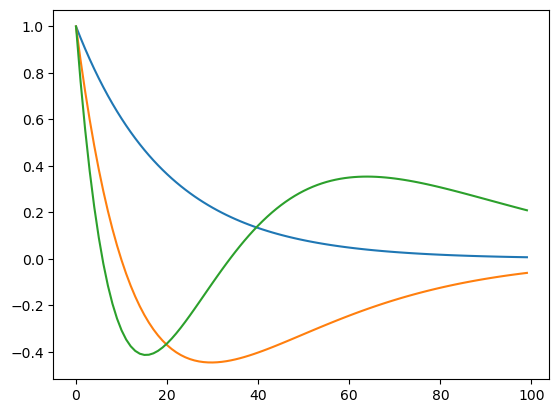

In [8]:
# Plotting the polynomials
arr = np.linspace(0, 10, 100)

plt.plot([order0(x) for x in arr], label="Order 0")
plt.plot([order1(x) for x in arr], label="Order 1")
plt.plot([order2(x) for x in arr], label="Order 2")

## Quasi Random Numbers Low Discrepancy Sequences

### Halton and Von der Corput Sequences in 2 dimensions

Text(0.5, 1.0, '2-Dimensional Halton Sequences with bases 2 and 3')

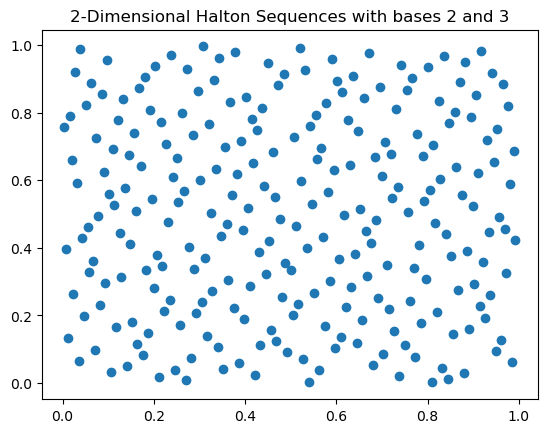

In [63]:
filepath = r"Outputs/Halton2D.csv"

# Load the data
df_data = pd.read_csv(filepath, header=None)

# Plot the data
plt.scatter(df_data.iloc[:, 0], df_data.iloc[:, 1])
plt.title("2-Dimensional Halton Sequences with bases 2 and 3")


Text(0.5, 1.0, 'Evolution of the Uniform on the first dimension')

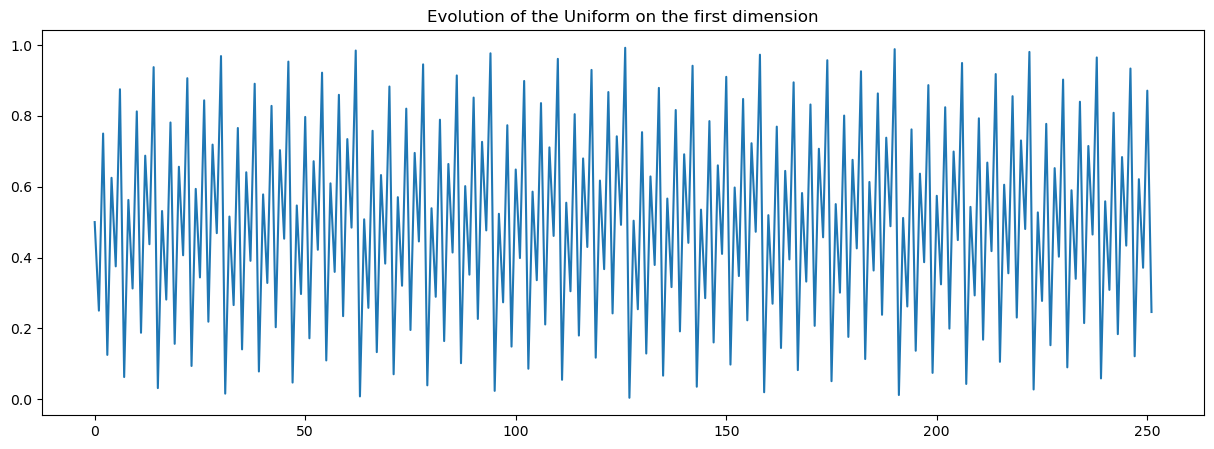

In [64]:
plt.figure(figsize=(15, 5))
plt.plot(df_data.iloc[:, 0])
plt.title("Evolution of the Uniform on the first dimension")

### Van der Corput/Halton Sequence -> Quasi Normal Sequences

Text(0.5, 1.0, 'Distribution of the Quasi Normal Numbers on dimension 0')

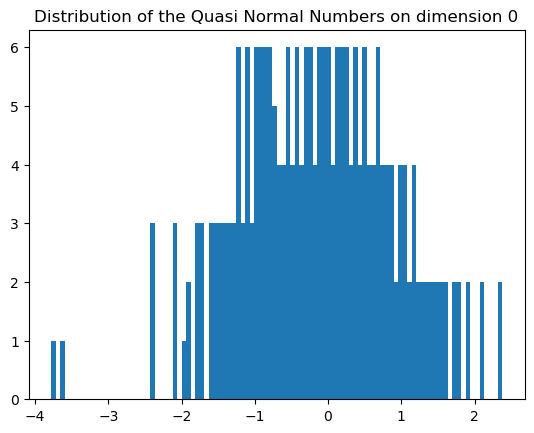

In [82]:
filepath = r"Outputs/QuasiNormal.csv"

# Load the data
df_data = pd.read_csv(filepath, header=None)

# Plot dimension
dim = 0

# Plot the data
plt.hist(df_data.iloc[:, dim-1], bins=100)
plt.title(f"Distribution of the Quasi Normal Numbers on dimension {dim}")

Text(0.5, 1.0, 'Evolution of the Quasi Normal on the 0 dimension')

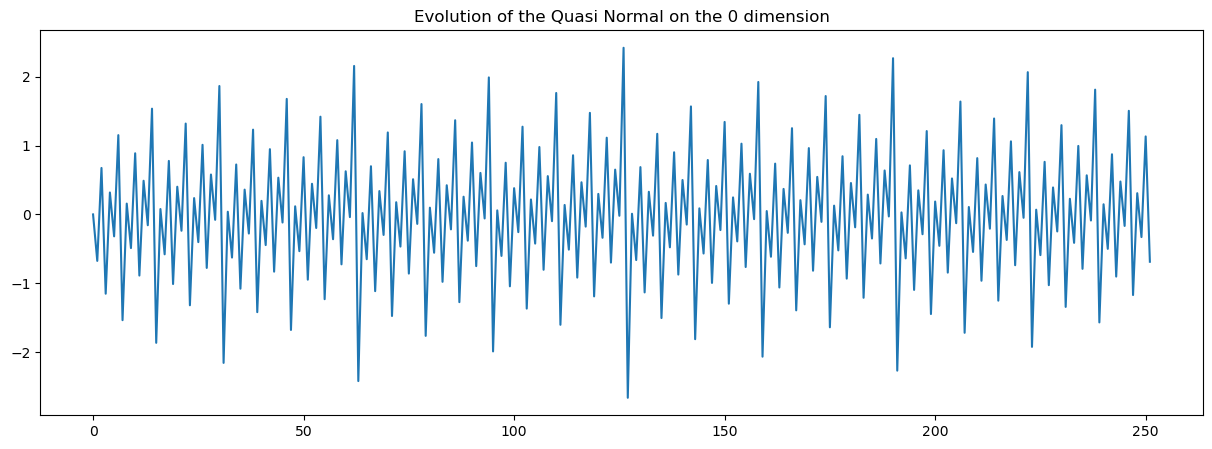

In [85]:
plt.figure(figsize=(15, 5))
plt.plot(df_data.iloc[:, dim])
plt.title(f"Evolution of the Quasi Normal on the {dim} dimension")

## Control Variate

In [291]:
def BSCall(spot, strike, vol, rate, matu):

    d1 = (np.log(spot/strike) + (rate - (vol ** 2)/2) * matu) / (vol * np.sqrt(matu))
    d2 = d1 - vol*np.sqrt(matu)

    return spot * norm.cdf(d1) - strike * np.exp(-rate * matu) * norm.cdf(d2)

print(f"Test price: {BSCall(100, 100, 0.26, 0.12, 1)}")

Test price: 16.113000030880293


In [248]:
df_covar = pd.read_csv(r"Inputs/matCov.csv", header=None)
print(df_covar)
matcovar = df_covar.values
L = np.linalg.cholesky(df_covar.values)
print(L)
print(L.T)
print(L.dot(L.T))
matvar = L.dot(L.T)

      0       1       2
0  0.01  0.0400  0.0200
1  0.04  0.3000  0.0375
2  0.02  0.0375  0.0625
[[ 0.1         0.          0.        ]
 [ 0.4         0.37416574  0.        ]
 [ 0.2        -0.11358603  0.09797048]]
[[ 0.1         0.4         0.2       ]
 [ 0.          0.37416574 -0.11358603]
 [ 0.          0.          0.09797048]]
[[0.01   0.04   0.02  ]
 [0.04   0.3    0.0375]
 [0.02   0.0375 0.0625]]


In [298]:
vecS = np.ones(3) * 100
vecW = np.array([1.0, 0.0, 0.0])

Pi = 1.0
for i in range(len(vecS)):
    Pi *= (vecS[i] ** vecW[i])

vecvar = np.zeros(3)
for i in range(3):
    # vecvar[i] = matvar.sum(axis=1)[i]
    vecvar[i] = matvar[i][i]

giga_term = vecW.T @ L @ L.T @ vecW
giga_term


spot = 100
strike = 100
rate = 0.05
matu = 1
adjrate = rate - 1/2 * vecW.T @ vecvar + 1/2 * giga_term
print(f"Adjusted rate: {adjrate}")
print(f"Giga term: {giga_term}")

Adjusted rate: 0.05
Giga term: 0.010000000000000002


## Longtsaff Schwarz Check

In [442]:
spot_path = r"Outputs/LS_simulations.csv"
value_path = r"Outputs/LS_values.csv"
time_path = r"Outputs/LS_times.csv"
exp_path = r"Outputs/LS_expected.csv"
x_path = r"Outputs/X.csv"
y_path = r"Outputs/Y.csv"

In [443]:
df_spots = pd.read_csv(spot_path, header=None)
df_value = pd.read_csv(value_path, header=None)
df_time = pd.read_csv(time_path, header=None)
df_path = pd.read_csv(exp_path, header=None)
df_x = pd.read_csv(x_path, header=None)
df_y = pd.read_csv(y_path, header=None)
df_y

,0
0,32.04140
1,8.43985
2,14.24050
3,19.71830
4,24.51660
...,...
995,14.73470
996,24.62870
997,7.98467
998,23.42470


In [ ]:
Xj = df_spots.iloc[:, 20]
Xj2 = Xj.apply(lambda x: x ** 2)
Xj3 = Xj.apply(lambda x: x ** 3)
Xj4 = Xj.apply(lambda x: x ** 4)
Xj5 = Xj.apply(lambda x: x ** 5)
X = pd.concat([Xj, Xj2, Xj3, Xj4, Xj5], axis=1)
Yj = np.exp(-0.05) * (1 - 0.8) * df_value.iloc[:, -1]

In [451]:
df_value

,0,1,2,3
0,27.3040,0.00000,32.6887,33.99870
1,0.0000,8.52467,0.0000,6.60699
2,18.5113,14.38360,0.0000,18.40470
3,0.0000,0.00000,0.0000,20.52300
4,24.8837,0.00000,25.0119,29.80760
...,...,...,...,...
995,0.0000,14.88280,0.0000,15.19230
996,17.9982,0.00000,25.1262,19.04270
997,0.0000,8.06492,0.0000,20.18420
998,20.4351,0.00000,23.8980,31.14080


In [445]:
model = LinearRegression(fit_intercept=False)
model.fit(X, Yj)
model.coef_

array([ 1.93036676e+01, -6.95924010e-01,  9.22490927e-03, -5.30152346e-05,
        1.11269509e-07])

In [449]:
matX = df_x.values
matY = df_y.values

betas = inv(matX.T @ matX) @ matX.T @ matY
betas

array([[ 5.96125146e+01],
       [-2.32711927e+00],
       [ 3.36863112e-02],
       [-2.14405112e-04],
       [ 5.08048609e-07]])

In [447]:
df_new_exp = X.dot(model.coef_)
# df_new_exp = X.dot(betas)
df_new_exp

0      11.625169
1       4.069104
2       8.756798
3       6.469474
4      11.092075
         ...    
995     5.936384
996     8.533714
997     6.694201
998     9.562777
999     5.778107
Length: 1000, dtype: float64

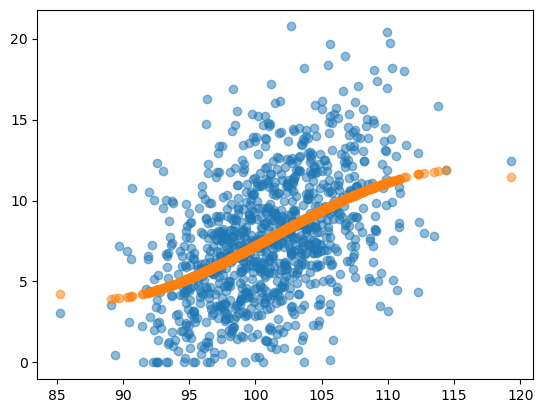

In [448]:
plt.scatter(Xj, Yj, alpha=0.5)
plt.scatter(Xj, df_new_exp, alpha=0.5)

<Axes: >

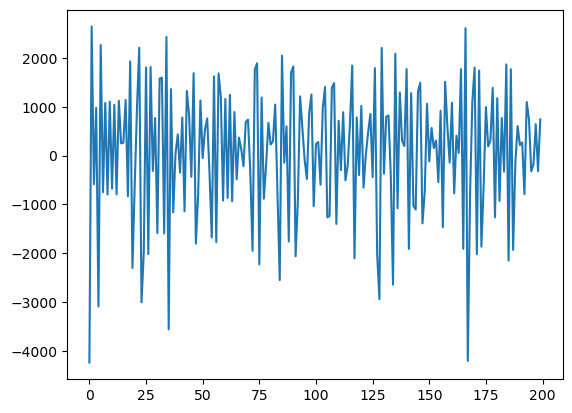

In [386]:
df_path.iloc[:, 0].plot()